# 1. Análisis Exploratorio de Datos (EDA) — Fraud Prevention Challenge

Este notebook explora el dataset de transacciones de Mercado Libre (`data/MercadoLibre Data
Scientist Technical Challenge - Dataset.csv`, 150,000 filas) para entender su estructura,
calidad y las señales disponibles antes de construir el pipeline de features y los modelos
(ver el roadmap en [`0_getting_started.ipynb`](0_getting_started.ipynb)).

Estructura de este notebook:
1. Carga y overview general
2. Hipótesis de las columnas anonimizadas (tabla resumen)
3. Valores nulos
4. Variable objetivo (`fraude`)
5. `monto` — clave para la ecuación de beneficio
6. `score` (score de fraude preexistente)
7. Variables categóricas (`g`, `j`, `o`, `p`)
8. Variables ordinales/binarias (`a`, `h`, `n`)
9. Variables numéricas restantes (`b`, `c`, `d`, `e`, `f`, `k`, `l`, `m`)
10. Correlaciones y relevancia de variables
11. Análisis temporal (`fecha`)
12. Conclusiones y próximos pasos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

DATA_PATH = "../data/MercadoLibre Data Scientist Technical Challenge - Dataset.csv"


## 1. Carga y overview general

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["fecha"])
print(f"Shape: {df.shape}")
df.head()


Shape: (150000, 19)


,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.6812,50084.12,50.0,0.000000,20.0,AR,1,cat_d26ab52,0.365475,2479.0,952.0,1,NaN,Y,2020-03-20 09:28:19,57.63,100,0
1,4,0.6694,66005.49,0.0,0.000000,2.0,AR,1,cat_ea962fb,0.612728,2603.0,105.0,1,Y,Y,2020-03-09 13:58:28,40.19,25,0
2,4,0.4718,7059.05,4.0,0.463488,92.0,BR,25,cat_4c2544e,0.651835,2153.0,249.0,1,Y,Y,2020-04-08 12:25:55,5.77,23,0
3,4,0.7260,10043.10,24.0,0.046845,43.0,BR,43,cat_1b59ee3,0.692728,4845.0,141.0,1,N,Y,2020-03-14 11:46:13,40.89,23,0
4,4,0.7758,16584.42,2.0,0.154616,54.0,BR,0,cat_9bacaa5,0.201354,2856.0,18.0,1,Y,N,2020-03-23 14:17:13,18.98,71,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   a       150000 non-null  int64         
 1   b       137016 non-null  float64       
 2   c       137016 non-null  float64       
 3   d       149635 non-null  float64       
 4   e       150000 non-null  float64       
 5   f       149989 non-null  float64       
 6   g       149806 non-null  str           
 7   h       150000 non-null  int64         
 8   j       150000 non-null  str           
 9   k       150000 non-null  float64       
 10  l       149989 non-null  float64       
 11  m       149635 non-null  float64       
 12  n       150000 non-null  int64         
 13  o       41143 non-null   str           
 14  p       150000 non-null  str           
 15  fecha   150000 non-null  datetime64[us]
 16  monto   150000 non-null  float64       
 17  score   150000 non-null  int64         


In [4]:
print(f"Filas duplicadas: {df.duplicated().sum()}")


Filas duplicadas: 0


El dataset tiene **150,000 transacciones** y **19 columnas**: variables anonimizadas
`a`..`p`, `fecha`, `monto`, un `score` de fraude preexistente (0-100) y la variable objetivo
`fraude` (0/1). No hay filas duplicadas.

## 2. Hipótesis de las columnas anonimizadas

Los nombres de las columnas están anonimizados, pero sus distribuciones, patrones de nulos
y relación con el target dan indicios fuertes sobre qué podría representar cada una. Estas
hipótesis **guían, pero no reemplazan**, el análisis estadístico detallado que sigue en el
resto del notebook.

| Columna | Tipo usado aquí | Hipótesis | Evidencia clave |
|---|---|---|---|
| `a` | categórica (4 niveles) | Canal o tipo de método de pago | El nivel 4 es 85.7% de las filas y tiene la tasa de fraude más baja (~4.5%) vs. 7.8-9.4% en los niveles minoritarios |
| `b` | numérica [0,1] | Score de similitud/confianza (ej. coincidencia de dispositivo o email) | Mismos 12,984 nulos exactos que `c` (100% de solapamiento) → probablemente generadas por el mismo paso de enriquecimiento |
| `c` | numérica, rango amplio | Historial monetario (ej. saldo de cuenta, GMV histórico, límite de crédito) | Escala mucho mayor que `monto` (máx ≈1.39M); mismos nulos que `b` |
| `d` | numérica, capada en 50 | Métrica de recencia/antigüedad capada (ej. días desde la última compra) | Distribución decreciente de 0 a 49 y luego un salto grande justo en el valor máximo: 25.7% de las filas valen exactamente 50 |
| `e` | numérica, sesgada a 0 | Un ratio/tasa (ej. proporción de transacciones rechazadas) | 43.4% de los valores son exactamente 0, sin nulos, forma de ratio; correlación de Spearman de -0.65 con `monto` |
| `f` | numérica, cola pesada | Conteo de eventos previos (compras, intentos de login) | Valores enteros, extremadamente sesgada a la derecha (skew ≈126), con un mínimo de -5 (posible ajuste/corrección) |
| `g` | categórica (51 valores) | País de la transacción | Los valores son literalmente códigos de país (BR, AR, UY, US...); `BR` concentra ~74% del volumen |
| `h` | numérica entera (0-58) | Conteo acotado de eventos (ej. compras previas del comprador) | 59 valores enteros distintos, sin nulos, distribución decreciente desde 0 |
| `j` | categórica alta cardinalidad (8,324 valores) | Categoría de producto o rubro (tipo MCC) | Prefijo `cat_` + código hash; tasas de fraude muy dispersas entre categorías (hasta ~25% en algunas con volumen relevante, vs. 5% global) |
| `k` | numérica [0,1] | **Identificador único de la transacción** (hash/UUID normalizado a [0,1]), no una variable de negocio | Sus 150,000 valores son **todos distintos** (tantos como filas tiene el dataset), distribución uniforme y sin relación con el fraude (Spearman ≈ 0.002) — el patrón típico de un ID, no de una feature |
| `l` | numérica (0-7,544) | Límite de crédito disponible o antigüedad de cuenta | Mayor en transacciones legítimas (2,351 vs. 1,432 en fraude); Spearman 0.67 con `f` |
| `m` | numérica (0-2,225) | Historial de compras o GMV acumulado | Mayor en legítimas (307 vs. 169 en fraude); Spearman 0.74 con `d` (fuerte relación con la métrica de recencia) |
| `n` | binaria (0/1) | Flag de verificación (ej. email o teléfono verificado) | 90.2% tiene `n=1` con tasa de fraude baja (3.8%); el 9.8% con `n=0` tiene tasa de fraude mucho mayor (16.1%) |
| `o` | binaria Y/N, 72.6% nulos | Resultado de una verificación adicional aplicada solo a un subconjunto (ej. autenticación reforzada) | Cuando se aplica y da `N`, la tasa de fraude sube a 21.8%; con `Y` baja a 6.5%; cuando no se aplica (nulo) cae a 2.1% |
| `p` | binaria Y/N, sin nulos | Comprador recurrente / cuenta con historial | `Y` (55.4% de filas) tiene tasa de fraude baja (2.9%) vs. `N` con 7.6% |
| `score` | numérica (0-100) | Score de riesgo de un proveedor externo o modelo previo | Relación no lineal con el fraude (pico ~16% en el bucket 80-100); es la variable con mayor *mutual information* respecto al target (ver Sección 10) |
| `monto` | numérica | Monto de la transacción (dado por el negocio) | Definida en el enunciado; media más alta en fraude (72.97) que en legítimas (41.97) |

**Nota sobre `k`:** al ser un identificador único (una fila = un valor distinto), no debe
usarse como feature predictiva — un modelo con acceso a un ID único puede memorizar en vez
de generalizar, y ese ID tampoco existiría de la misma forma para una transacción nueva en
producción. Se descarta como feature en el notebook de feature engineering.

A continuación, dos vistazos rápidos que acompañan la tabla: la distribución de las
variables categóricas/discretas clave y su tasa de fraude relativa a la tasa global (5%).

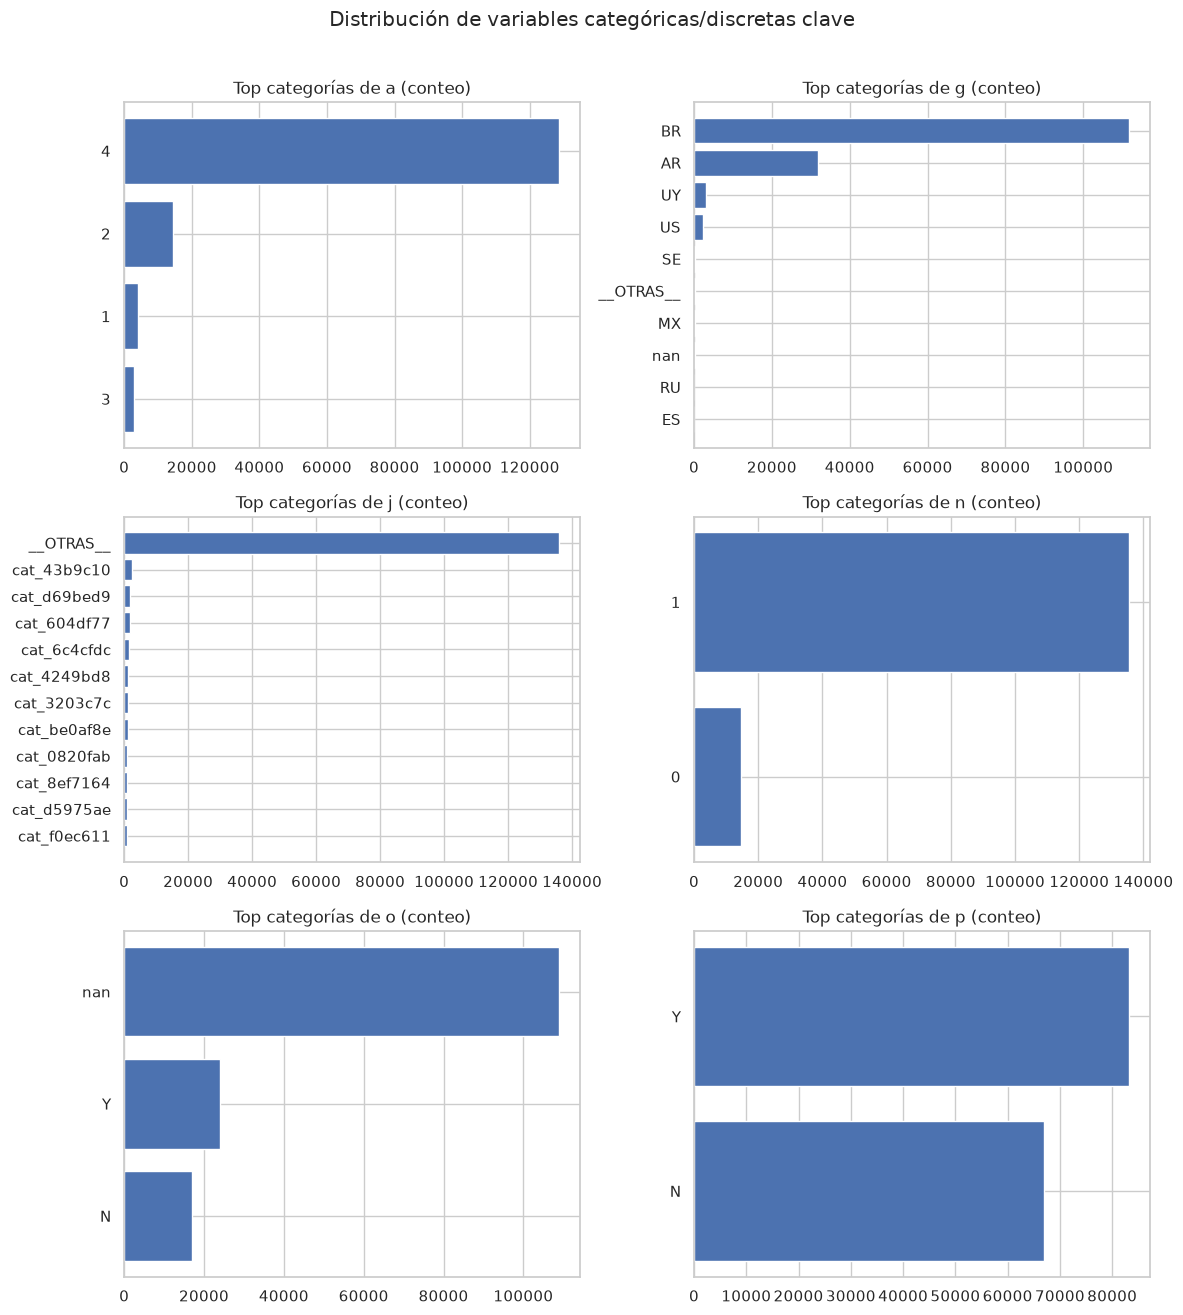

In [5]:
cat_cols_overview = ["a", "g", "j", "n", "o", "p"]
top_n = {"a": 10, "g": 10, "j": 12, "n": 10, "o": 10, "p": 10}

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
for ax, col in zip(axes.ravel(), cat_cols_overview):
    vc = df[col].value_counts(dropna=False)
    if len(vc) > top_n[col]:
        top = vc.head(top_n[col] - 1)
        otras = pd.Series({"__OTRAS__": vc.iloc[top_n[col] - 1 :].sum()})
        vc = pd.concat([top, otras])
    vc = vc.sort_values(ascending=True)
    ax.barh([str(i) for i in vc.index], vc.values, color="#4C72B0")
    ax.set_title(f"Top categorías de {col} (conteo)")
fig.suptitle("Distribución de variables categóricas/discretas clave", y=1.01)
plt.tight_layout()
plt.show()


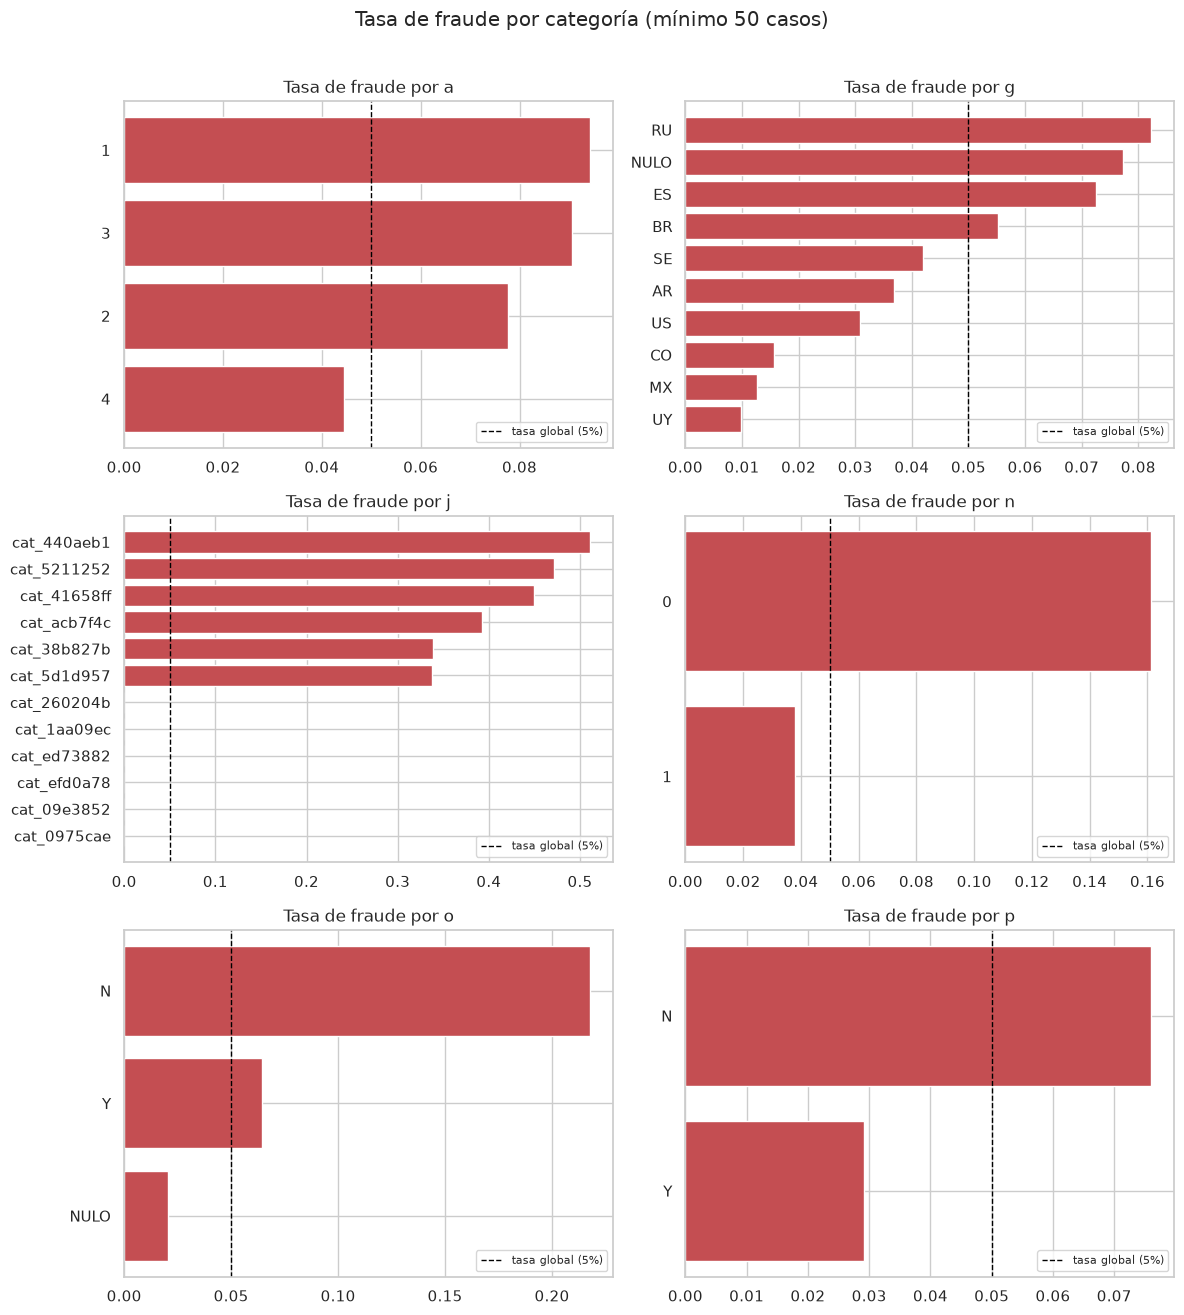

In [6]:
overall_rate = df["fraude"].mean()

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
for ax, col in zip(axes.ravel(), cat_cols_overview):
    grp = df.groupby(col, dropna=False)["fraude"].agg(["mean", "count"])
    grp = grp[grp["count"] >= 50].sort_values("mean", ascending=True)
    if len(grp) > 12:
        grp = pd.concat([grp.head(6), grp.tail(6)])
    labels = [str(i) if not pd.isna(i) else "NULO" for i in grp.index]
    ax.barh(labels, grp["mean"], color="#C44E52")
    ax.axvline(overall_rate, color="black", linestyle="--", linewidth=1, label="tasa global (5%)")
    ax.set_title(f"Tasa de fraude por {col}")
    ax.legend(fontsize=8)
fig.suptitle("Tasa de fraude por categoría (mínimo 50 casos)", y=1.01)
plt.tight_layout()
plt.show()


Estos dos paneles confirman visualmente varias de las hipótesis de la tabla: `o` y `j` son
las que muestran mayor dispersión en tasa de fraude entre sus niveles (consistente con ser
señales fuertes), mientras que `a`, `n` y `p` diferencian claramente un segmento minoritario
de mayor riesgo del segmento mayoritario de bajo riesgo.

## 3. Valores nulos

In [7]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(df) * 100).round(2)
nulls_summary = pd.DataFrame({"nulos": nulls, "pct_nulos": nulls_pct})
nulls_summary[nulls_summary["nulos"] > 0]


,nulos,pct_nulos
o,108857,72.57
c,12984,8.66
b,12984,8.66
m,365,0.24
d,365,0.24
g,194,0.13
f,11,0.01
l,11,0.01


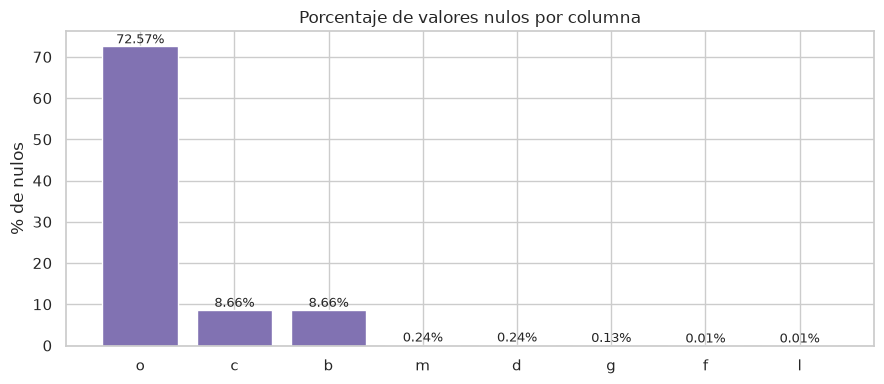

In [8]:
plot_nulls = nulls_summary[nulls_summary["nulos"] > 0].sort_values("pct_nulos", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(plot_nulls.index, plot_nulls["pct_nulos"], color="#8172B2")
for i, v in enumerate(plot_nulls["pct_nulos"]):
    ax.text(i, v, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("% de nulos")
ax.set_title("Porcentaje de valores nulos por columna")
plt.tight_layout()
plt.show()


Hallazgos:
- **`o`** tiene ~73% de nulos — es la columna con más missingness, con diferencia.
- **`b`** y **`c`** tienen ~8.7% de nulos cada una.
- **`d`**, **`m`** tienen ~0.24% de nulos; **`f`**, **`l`** ~0.007%; **`g`** ~0.13%.
- El resto de columnas no tiene nulos.

Como se vio en la Sección 2, el nulo en `o` **no es aleatorio** (MNAR): la tasa de fraude
difiere fuertemente entre transacciones con `o` presente vs. ausente, por lo que conviene
tratarlo como señal (flag / categoría "missing") en vez de imputarlo ciegamente.

## 4. Variable objetivo (`fraude`)

In [9]:
fraud_counts = df["fraude"].value_counts()
fraud_rate = df["fraude"].value_counts(normalize=True)
pd.DataFrame({"cantidad": fraud_counts, "proporcion": fraud_rate})


,cantidad,proporcion
fraude,,
0,142500,0.95
1,7500,0.05


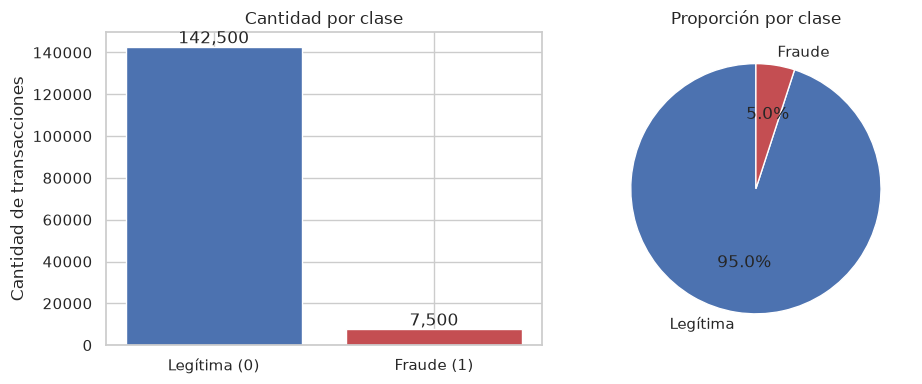

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = df["fraude"].value_counts().sort_index()

axes[0].bar(["Legítima (0)", "Fraude (1)"], counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")
axes[0].set_title("Cantidad por clase")
axes[0].set_ylabel("Cantidad de transacciones")

axes[1].pie(
    counts.values,
    labels=["Legítima", "Fraude"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#C44E52"],
    startangle=90,
)
axes[1].set_title("Proporción por clase")
plt.tight_layout()
plt.show()


El dataset está **fuertemente desbalanceado**: 95% de las transacciones son legítimas
(142,500) y solo 5% son fraude (7,500). Esto debe manejarse en el modelado (`class_weight`,
resampling, o eligiendo directamente el umbral de decisión en base a la ecuación de
beneficio en vez de un umbral de 0.5) y en la elección de métricas de evaluación (accuracy
no es informativo con este desbalance; se preferirán ROC-AUC, PR-AUC, F1/F6 y la métrica de
negocio).

## 5. `monto` — clave para la ecuación de beneficio

In [11]:
df.groupby("fraude")["monto"].describe()


,count,mean,std,min,25%,50%,75%,max
fraude,,,,,,,,
0,142500.0,41.973326,85.708924,0.02,9.30,20.18,40.0225,3696.35
1,7500.0,72.969483,164.843328,0.21,10.82,25.87,59.0575,3424.81


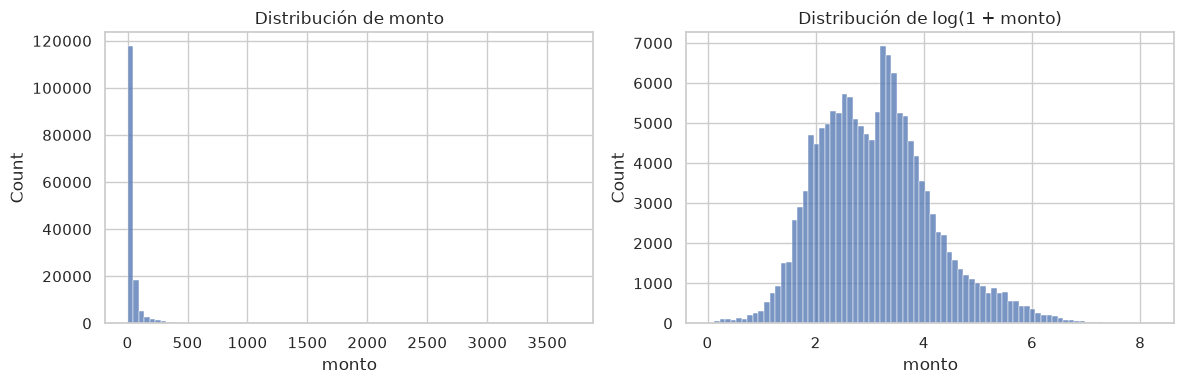

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["monto"], bins=80, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de monto")
sns.histplot(np.log1p(df["monto"]), bins=80, ax=axes[1], color="#4C72B0")
axes[1].set_title("Distribución de log(1 + monto)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_1277000/2667400798.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legítima", "Fraude"])


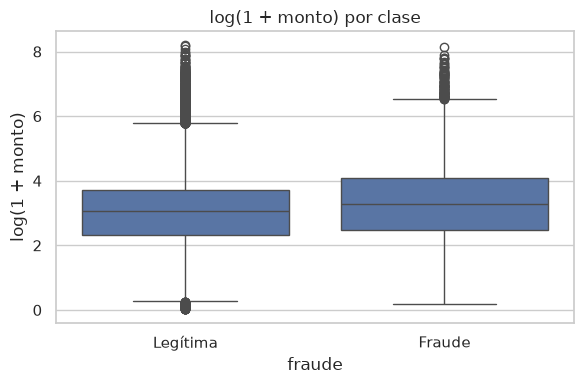

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_df = df.assign(log_monto=np.log1p(df["monto"]))
sns.boxplot(data=plot_df, x="fraude", y="log_monto", ax=ax)
ax.set_xticklabels(["Legítima", "Fraude"])
ax.set_ylabel("log(1 + monto)")
ax.set_title("log(1 + monto) por clase")
plt.tight_layout()
plt.show()


El monto está muy sesgado a la derecha (de ahí la vista en escala log). Las transacciones
**fraudulentas tienen, en promedio, un monto mayor** que las legítimas (media ≈ 72.97 vs.
41.97) y también mayor dispersión. Esto es especialmente relevante dada la ecuación de
beneficio del notebook `0_getting_started`: un fraude de monto alto que pase desapercibido
es mucho más costoso que uno de monto bajo, por lo que el modelo no solo debe maximizar la
detección de fraude en cantidad de casos, sino ponderar por monto (la métrica de negocio ya
lo hace).

## 6. `score` (score de fraude preexistente)

In [14]:
df["score_bucket"] = pd.cut(df["score"], bins=[-1, 20, 40, 60, 80, 100])
score_fraud = df.groupby("score_bucket", observed=True)["fraude"].agg(["mean", "count"])
score_fraud.rename(columns={"mean": "tasa_fraude"})


,tasa_fraude,count
score_bucket,,
"(-1, 20]",0.037699,33874
"(20, 40]",0.012825,29863
"(40, 60]",0.010280,29962
"(60, 80]",0.042919,29987
"(80, 100]",0.161321,26314


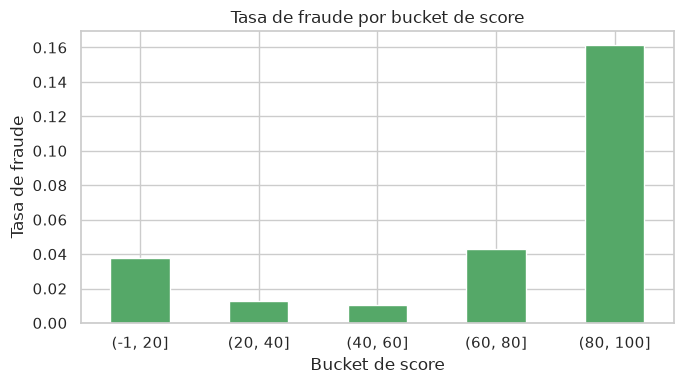

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
score_fraud["mean"].plot(kind="bar", ax=ax, color="#55A868")
ax.set_ylabel("Tasa de fraude")
ax.set_xlabel("Bucket de score")
ax.set_title("Tasa de fraude por bucket de score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


La relación entre `score` y `fraude` **no es monótona**: el bucket 80-100 concentra una tasa
de fraude muy alta (~16%), muy por encima del resto, pero el bucket bajo (0-20) también
muestra una tasa algo elevada (~3.8%) frente a los buckets intermedios (~1%). Esto sugiere
que `score` es una señal útil pero no suficiente por sí sola, y que su relación con el
target no es lineal — un modelo basado en árboles (Random Forest/XGBoost/LightGBM) puede
capturar esta no linealidad mejor que uno lineal, o se puede binnear `score` como feature
categórica adicional.

## 7. Variables categóricas (`g`, `j`, `o`, `p`)

### `g` — país

In [16]:
df["g"].value_counts(dropna=False).head(10)


g
BR     111628
AR      31964
UY       2967
US       2273
SE        358
MX        236
NaN       194
RU         73
ES         69
CO         64
Name: count, dtype: int64

In [17]:
top_countries = df["g"].value_counts().head(8).index
fraud_by_country = (
    df[df["g"].isin(top_countries)]
    .groupby("g")["fraude"]
    .agg(["mean", "count"])
    .sort_values("count", ascending=False)
)
fraud_by_country.rename(columns={"mean": "tasa_fraude"})


,tasa_fraude,count
g,,
BR,0.055201,111628
AR,0.036885,31964
UY,0.009774,2967
US,0.030796,2273
SE,0.041899,358
MX,0.012712,236
RU,0.082192,73
ES,0.072464,69


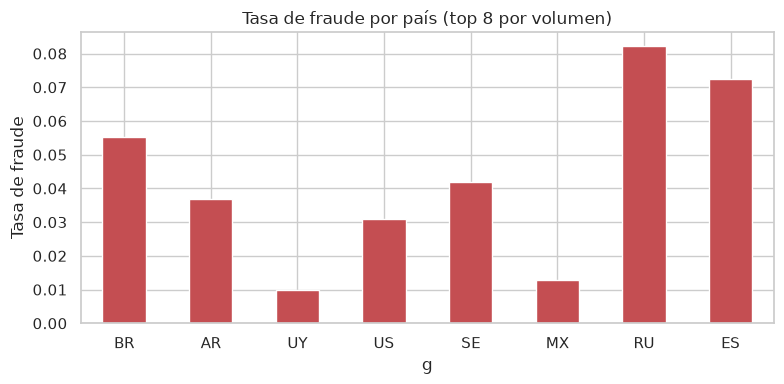

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
fraud_by_country["mean"].plot(kind="bar", ax=ax, color="#C44E52")
ax.set_ylabel("Tasa de fraude")
ax.set_title("Tasa de fraude por país (top 8 por volumen)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


`BR` y `AR` concentran la gran mayoría del volumen (111,628 y 31,964 transacciones
respectivamente). La tasa de fraude varía por país (de ~1% en `UY`/`MX` a >5% en `BR`/`RU`),
por lo que `g` es una variable categórica útil (baja cardinalidad, ~51 valores incluyendo
nulos).

### `j` — categoría (alta cardinalidad)

In [19]:
print(f"Categorías únicas en j: {df['j'].nunique()}")
df["j"].value_counts().head(10)


Categorías únicas en j: 8324


j
cat_43b9c10    2331
cat_d69bed9    1799
cat_604df77    1784
cat_6c4cfdc    1449
cat_4249bd8    1191
cat_3203c7c    1093
cat_be0af8e    1040
cat_0820fab     938
cat_8ef7164     909
cat_d5975ae     878
Name: count, dtype: int64

In [20]:
value_counts_j = df["j"].value_counts()
common_categories = value_counts_j[value_counts_j >= 100].index
top_fraud_categories = (
    df[df["j"].isin(common_categories)]
    .groupby("j")["fraude"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .head(10)
)
top_fraud_categories.rename(columns={"mean": "tasa_fraude"})


,tasa_fraude,count
j,,
cat_d9753d4,0.253863,453
cat_c84c9c3,0.198381,247
cat_ff61796,0.165289,121
cat_43b9c10,0.163020,2331
cat_23212a0,0.156069,346
cat_e790de8,0.152482,282
cat_f79d120,0.151163,172
cat_e5ca240,0.150142,353
cat_3f81bbe,0.145985,137


`j` tiene **8,324 categorías distintas** — demasiada cardinalidad para one-hot encoding.
Sin embargo, hay categorías con tasas de fraude muy por encima del promedio (hasta ~25% en
categorías con volumen relevante, frente al 5% general), lo que la convierte en una señal
potencialmente fuerte si se codifica bien (frequency encoding o target/mean encoding con
regularización, para evitar leakage y overfitting a categorías de bajo volumen).

### `o` y `p` — variables binarias Y/N

In [21]:
df["o"].value_counts(dropna=False)


o
NaN    108857
Y       24091
N       17052
Name: count, dtype: int64

In [22]:
df.groupby(df["o"].isna())["fraude"].agg(["mean", "count"]).rename(
    index={True: "o es nulo", False: "o presente"}, columns={"mean": "tasa_fraude"}
)


,tasa_fraude,count
o,,
o presente,0.12792,41143
o es nulo,0.02055,108857


Como se anticipó en la sección de nulos, la ausencia de `o` es altamente informativa: cuando
`o` está presente la tasa de fraude es **12.8%**, mientras que cuando es nulo cae a **2.1%**
(muy por debajo del promedio general de 5%). El missingness no es aleatorio (MNAR) — se
recomienda crear un flag `o_is_null` y tratar los nulos como una categoría explícita en vez
de imputar con la moda u otro valor.

In [23]:
df.groupby("p")["fraude"].agg(["mean", "count"]).rename(columns={"mean": "tasa_fraude"})


,tasa_fraude,count
p,,
N,0.075952,66871
Y,0.029123,83129


`p` no tiene nulos y también muestra diferencia de tasa de fraude entre sus dos valores
(7.6% en `N` vs. 2.9% en `Y`), por lo que aporta señal directamente utilizable.

## 8. Variables ordinales/binarias (`a`, `h`, `n`)

In [24]:
for col in ["a", "h", "n"]:
    print(f"{col}: {df[col].nunique()} valores únicos, rango [{df[col].min()}, {df[col].max()}]")


a: 4 valores únicos, rango [1, 4]
h: 59 valores únicos, rango [0, 58]
n: 2 valores únicos, rango [0, 1]


In [25]:
df.groupby("a")["fraude"].agg(["mean", "count"]).rename(columns={"mean": "tasa_fraude"})


,tasa_fraude,count
a,,
1,0.094160,4195
2,0.077758,14378
3,0.090590,2848
4,0.044556,128579


In [26]:
df.groupby("n")["fraude"].agg(["mean", "count"]).rename(columns={"mean": "tasa_fraude"})


,tasa_fraude,count
n,,
0,0.161125,14647
1,0.037975,135353


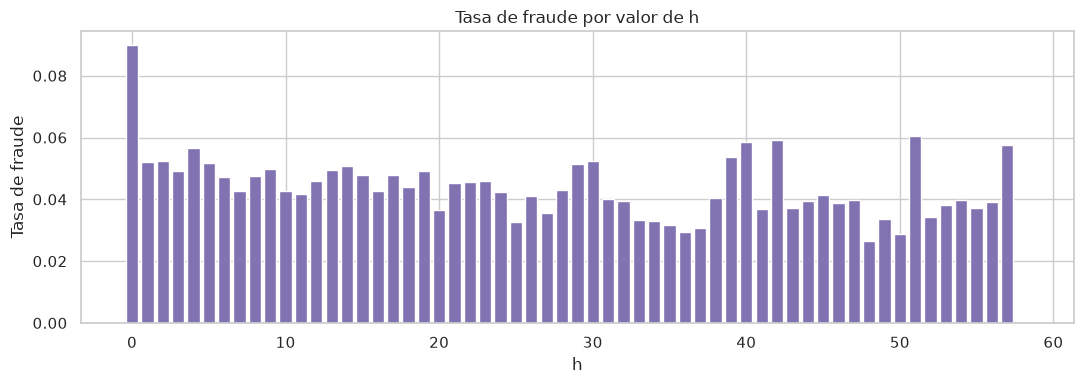

In [27]:
h_fraud = df.groupby("h")["fraude"].agg(["mean", "count"])
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(h_fraud.index, h_fraud["mean"], color="#8172B2")
ax.set_xlabel("h")
ax.set_ylabel("Tasa de fraude")
ax.set_title("Tasa de fraude por valor de h")
plt.tight_layout()
plt.show()


`a` (4 valores), `n` (binaria) y `h` (59 valores enteros, tipo contador) muestran diferencias
de tasa de fraude entre sus niveles, por lo que son candidatas a incluirse tal cual (`a`,
`h`) o como variable binaria (`n`) en el modelo.

## 9. Variables numéricas restantes (`b`, `c`, `d`, `e`, `f`, `k`, `l`, `m`)

In [28]:
num_cols = ["b", "c", "d", "e", "f", "k", "l", "m"]
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
b,137016.0,0.728115,0.132943,0.000000,0.678400,0.755500,0.806500,1.000000e+00
c,137016.0,260445.107044,846436.141626,0.160000,9679.915000,43711.655000,145443.627500,1.387874e+07
d,149635.0,21.677669,20.062146,0.000000,2.000000,14.000000,50.000000,5.000000e+01
e,150000.0,0.220641,2.434995,0.000000,0.000000,0.104875,0.282938,8.333333e+02
f,149989.0,51.169352,709.472904,-5.000000,1.000000,8.000000,33.000000,1.452740e+05
k,150000.0,0.497532,0.288348,0.000004,0.246819,0.495990,0.746508,9.999948e-01
l,149989.0,2305.409403,1712.379601,0.000000,910.000000,1937.000000,3445.000000,7.544000e+03
m,149635.0,299.969579,321.075806,0.000000,42.000000,193.000000,459.000000,2.225000e+03


In [29]:
df.groupby("fraude")[num_cols].mean().T.rename(
    columns={0: "media_legitima", 1: "media_fraude"}
)


fraude,media_legitima,media_fraude
b,0.726945,0.750986
c,254082.178440,384770.684747
d,22.035508,14.868425
e,0.221904,0.196641
f,52.876657,18.733067
k,0.497374,0.500543
l,2351.383138,1431.975867
m,306.846923,169.102128


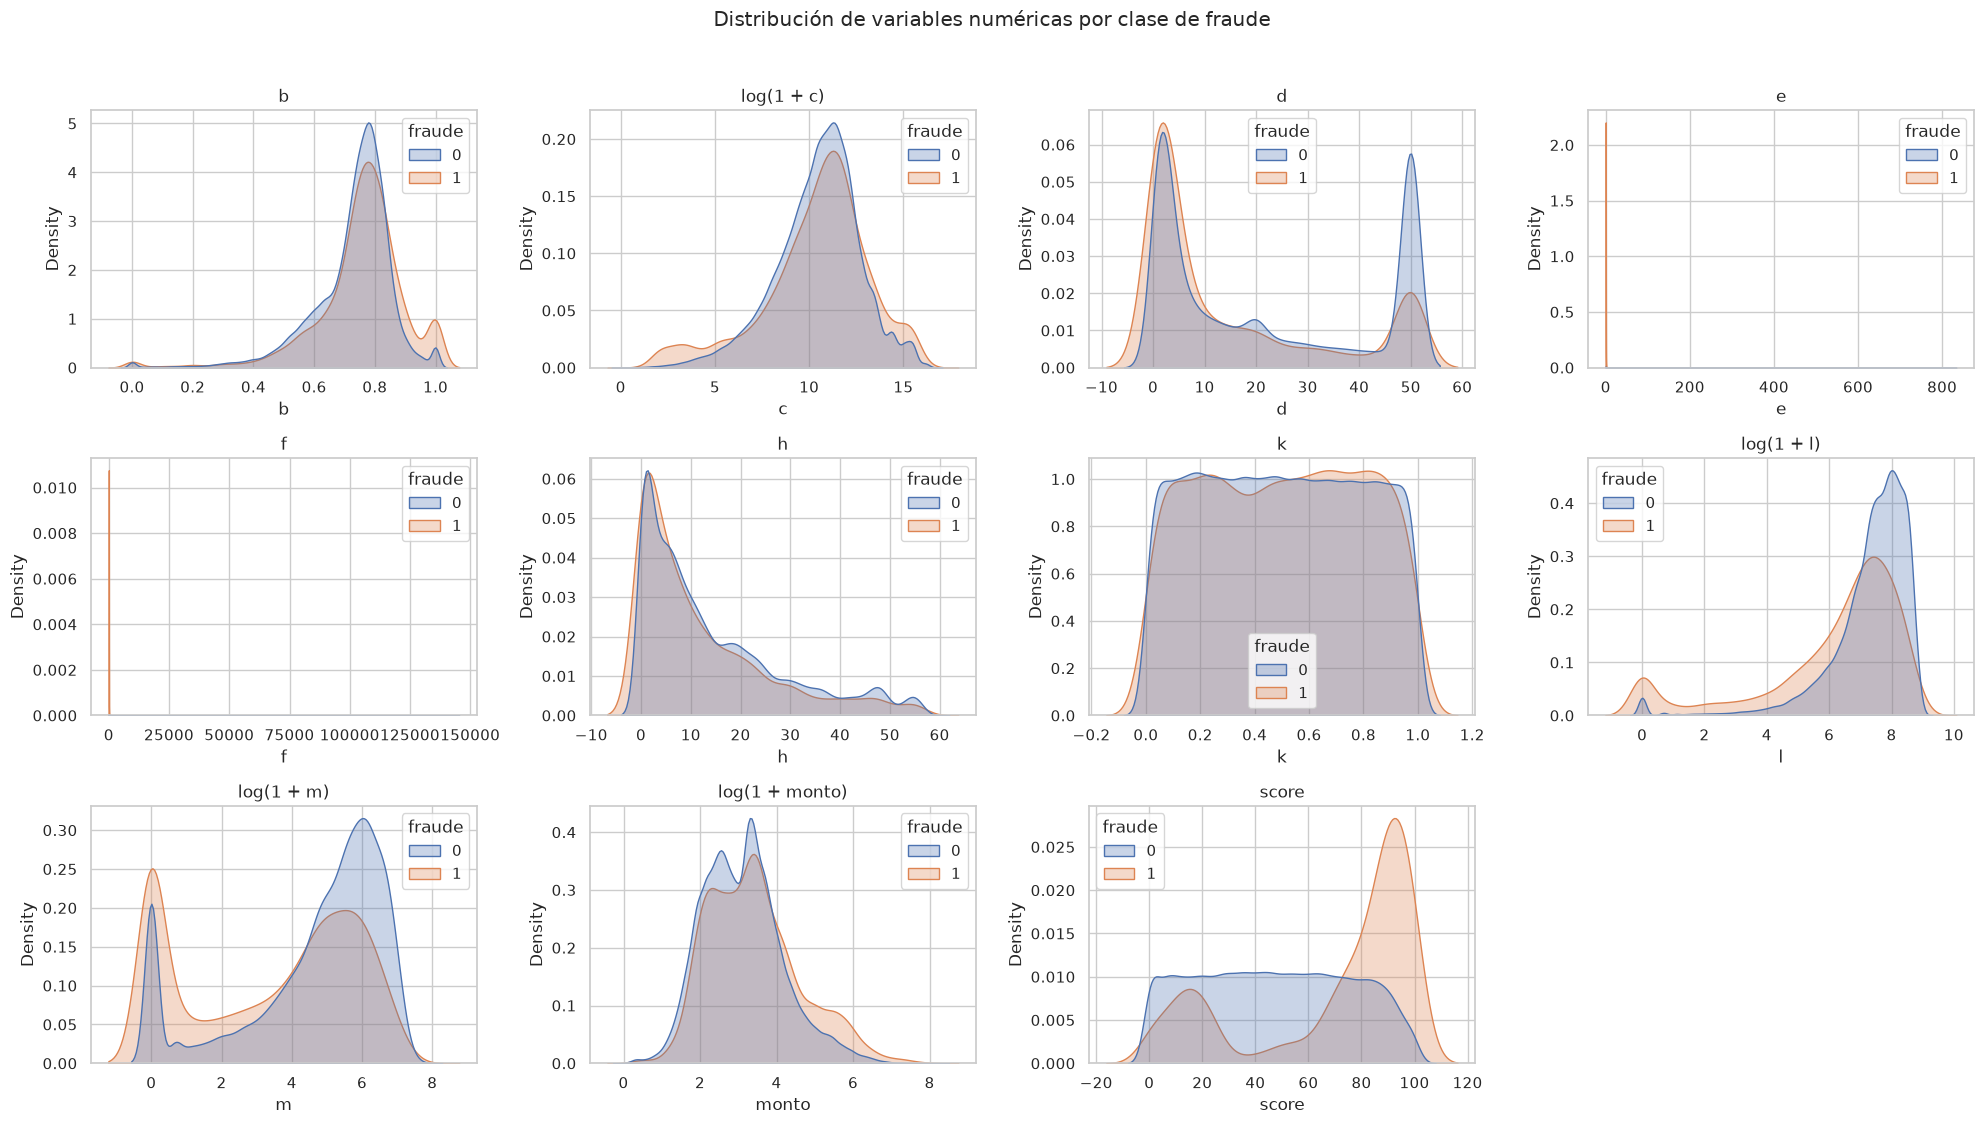

In [30]:
num_cols_dist = ["b", "c", "d", "e", "f", "h", "k", "l", "m", "monto", "score"]
log_cols_dist = {"c", "l", "m", "monto"}  # distribuciones muy sesgadas a la derecha

fig, axes = plt.subplots(3, 4, figsize=(20, 11))
axes = axes.ravel()
for ax, col in zip(axes, num_cols_dist):
    plot_df = df[[col, "fraude"]].dropna().copy()
    if col in log_cols_dist:
        plot_df[col] = np.log1p(plot_df[col])
        ax.set_title(f"log(1 + {col})")
    else:
        ax.set_title(col)
    sns.kdeplot(
        data=plot_df, x=col, hue="fraude", common_norm=False,
        fill=True, alpha=0.3, ax=ax, warn_singular=False,
    )
for ax in axes[len(num_cols_dist):]:
    ax.axis("off")
fig.suptitle("Distribución de variables numéricas por clase de fraude", y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1277000/4245615494.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legítima", "Fraude"])


/tmp/ipykernel_1277000/4245615494.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legítima", "Fraude"])


/tmp/ipykernel_1277000/4245615494.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legítima", "Fraude"])


/tmp/ipykernel_1277000/4245615494.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legítima", "Fraude"])


/tmp/ipykernel_1277000/4245615494.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legítima", "Fraude"])


...

/tmp/ipykernel_1277000/4245615494.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legítima", "Fraude"])


/tmp/ipykernel_1277000/4245615494.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legítima", "Fraude"])


/tmp/ipykernel_1277000/4245615494.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legítima", "Fraude"])


/tmp/ipykernel_1277000/4245615494.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legítima", "Fraude"])


/tmp/ipykernel_1277000/4245615494.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legítima", "Fraude"])


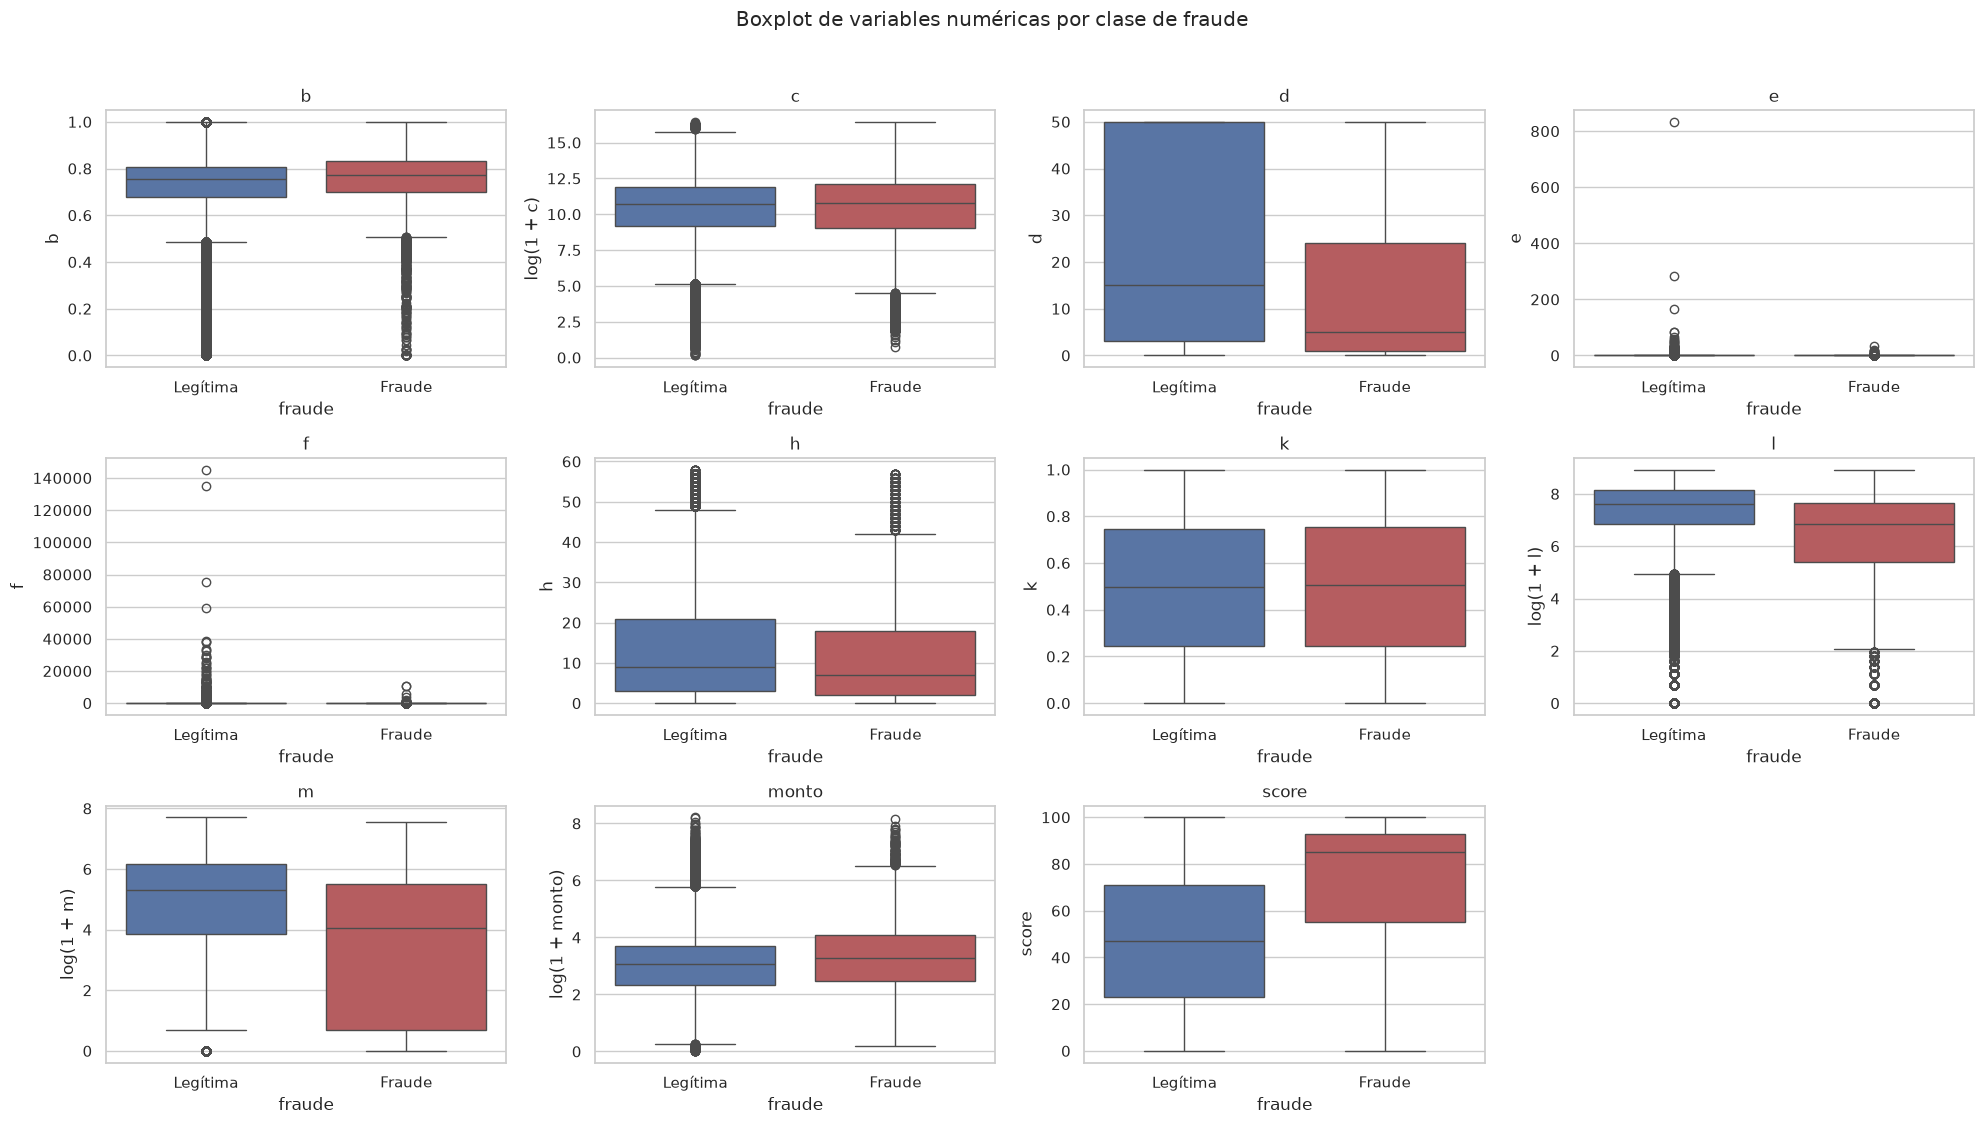

In [31]:
fig, axes = plt.subplots(3, 4, figsize=(20, 11))
axes = axes.ravel()
for ax, col in zip(axes, num_cols_dist):
    plot_df = df[[col, "fraude"]].dropna().copy()
    if col in log_cols_dist:
        plot_df[col] = np.log1p(plot_df[col])
        ylabel = f"log(1 + {col})"
    else:
        ylabel = col
    sns.boxplot(
        data=plot_df, x="fraude", y=col, ax=ax,
        palette={0: "#4C72B0", 1: "#C44E52"}, hue="fraude", legend=False,
    )
    ax.set_xticklabels(["Legítima", "Fraude"])
    ax.set_ylabel(ylabel)
    ax.set_title(col)
for ax in axes[len(num_cols_dist):]:
    ax.axis("off")
fig.suptitle("Boxplot de variables numéricas por clase de fraude", y=1.02)
plt.tight_layout()
plt.show()


Varias variables muestran medias claramente distintas entre clases: `c`, `k` son más altas
en transacciones fraudulentas, mientras que `d`, `f`, `l`, `m` son más bajas. `b` y `e`
muestran diferencias menores. Los boxplots complementan las densidades: para las variables
más sesgadas (`c`, `l`, `m`, `monto`) los outliers de alto valor son notoriamente más
frecuentes en las transacciones legítimas que en las fraudulentas para `l` y `m`, y al revés
para `monto` y `score`. Estas diferencias, junto con los nulos en `b`, `c`, `d`, `f`, `l`,
`m`, deberán tratarse en el feature engineering (imputación + transformación logarítmica
para las más sesgadas).

## 10. Correlaciones y relevancia de variables

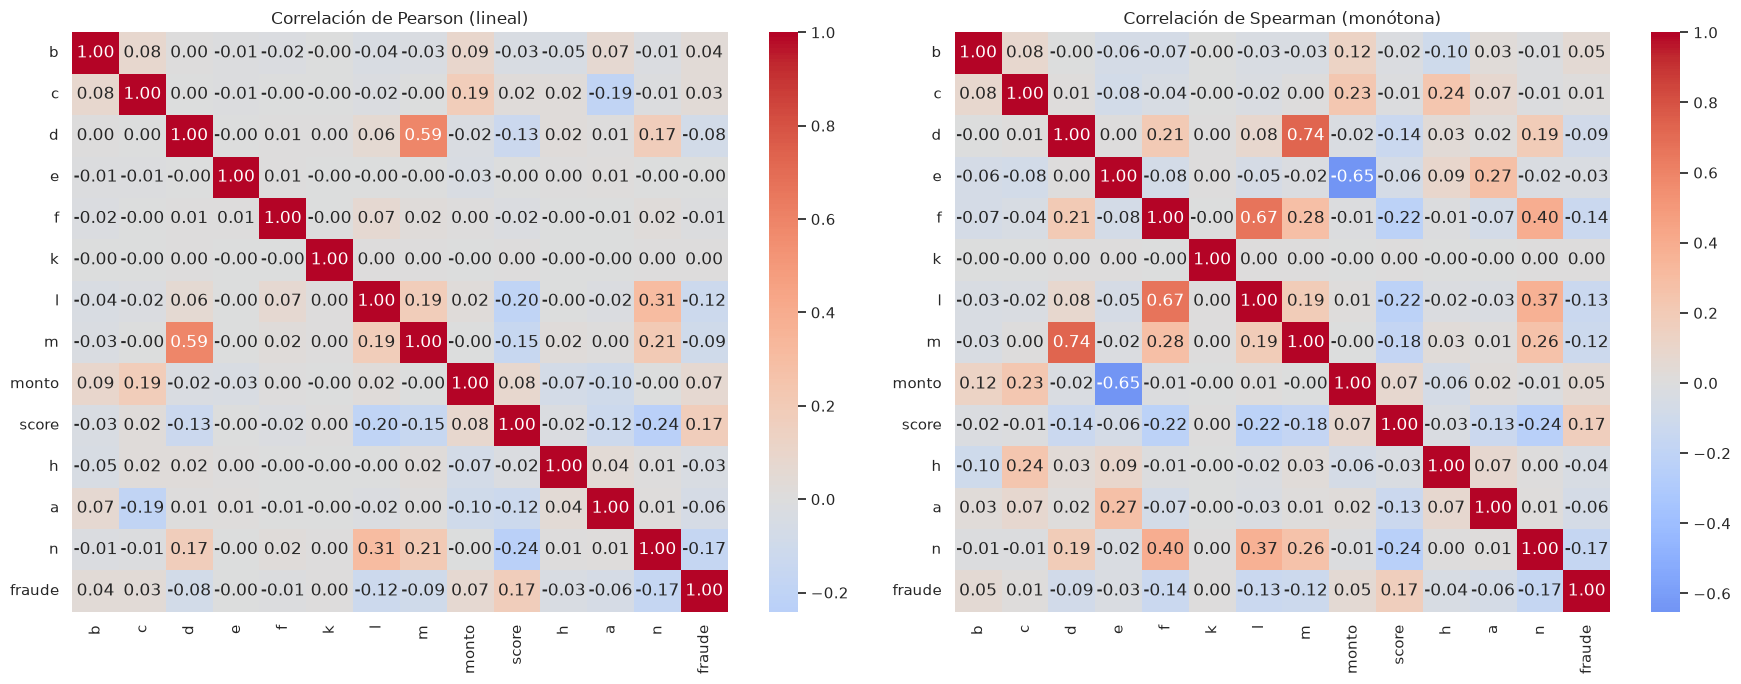

In [32]:
corr_cols = num_cols + ["monto", "score", "h", "a", "n", "fraude"]
pearson_corr = df[corr_cols].corr(method="pearson")
spearman_corr = df[corr_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Correlación de Pearson (lineal)")
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Correlación de Spearman (monótona)")
plt.tight_layout()
plt.show()


Ninguna variable numérica individual tiene una correlación lineal fuerte con `fraude`
(todas por debajo de ~0.15 en valor absoluto). El panel de Spearman agrega una lectura
adicional: revela relaciones monótonas fuertes **entre variables explicativas** que Pearson
no capta bien por la naturaleza capada/sesgada de algunas columnas — por ejemplo `d`-`m`
(0.74) y `f`-`l` (0.67) — sugiriendo que estos pares podrían compartir información (posible
redundancia a tener en cuenta al seleccionar features), y `e`-`monto` (-0.65), consistente
con la hipótesis de que `e` es un ratio derivado del monto.

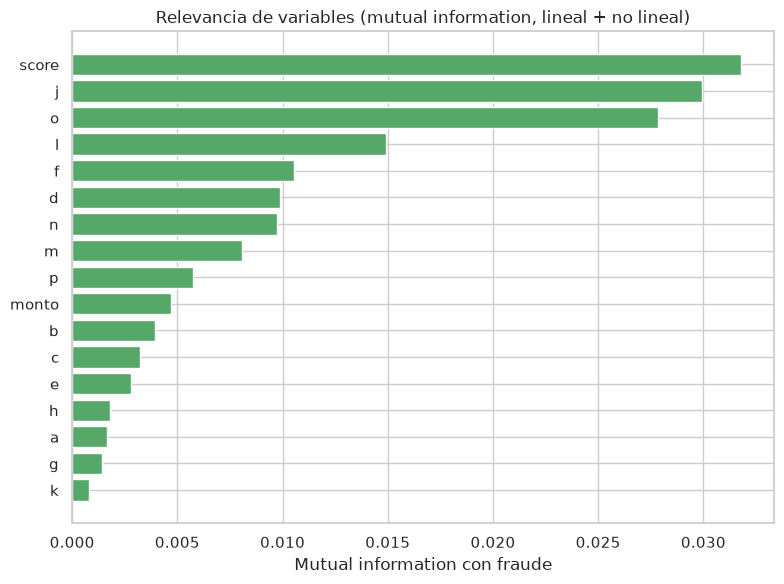

In [33]:
mi_feature_cols = [
    "a", "b", "c", "d", "e", "f", "g", "h", "j", "k", "l", "m", "n", "o", "p", "monto", "score"
]
X_mi = df[mi_feature_cols].copy()

cat_cols_mi = ["a", "g", "j", "n", "o", "p", "h"]
for c in cat_cols_mi:
    X_mi[c] = X_mi[c].fillna("__NA__").astype(str).astype("category").cat.codes

num_cols_mi = ["b", "c", "d", "e", "f", "k", "l", "m", "monto", "score"]
for c in num_cols_mi:
    X_mi[c] = X_mi[c].fillna(X_mi[c].median())

discrete_mask = [c in cat_cols_mi for c in mi_feature_cols]
mi_scores = mutual_info_classif(
    X_mi[mi_feature_cols], df["fraude"], discrete_features=discrete_mask, random_state=42
)
mi_series = pd.Series(mi_scores, index=mi_feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(mi_series.index, mi_series.values, color="#55A868")
ax.set_xlabel("Mutual information con fraude")
ax.set_title("Relevancia de variables (mutual information, lineal + no lineal)")
plt.tight_layout()
plt.show()


A diferencia de la correlación lineal, la *mutual information* también captura relaciones no
lineales (como la de `score`, vista en la Sección 6). Las variables más relevantes según
esta métrica son, en orden, **`score`, `j`, `o`, `l`, `f`** — coincidiendo con las señales
más fuertes identificadas a lo largo del notebook. `k` aparece entre las de menor
información, consistente con ser un identificador único (Sección 2) más que una variable de
negocio; `g` también aporta poco individualmente, aunque puede seguir siendo útil combinada
con otras variables.

## 11. Análisis temporal (`fecha`)

In [34]:
print(f"Rango de fechas: {df['fecha'].min()} a {df['fecha'].max()}")
print(f"Días cubiertos: {(df['fecha'].max() - df['fecha'].min()).days} días")


Rango de fechas: 2020-03-08 00:02:15 a 2020-04-21 23:59:56
Días cubiertos: 44 días


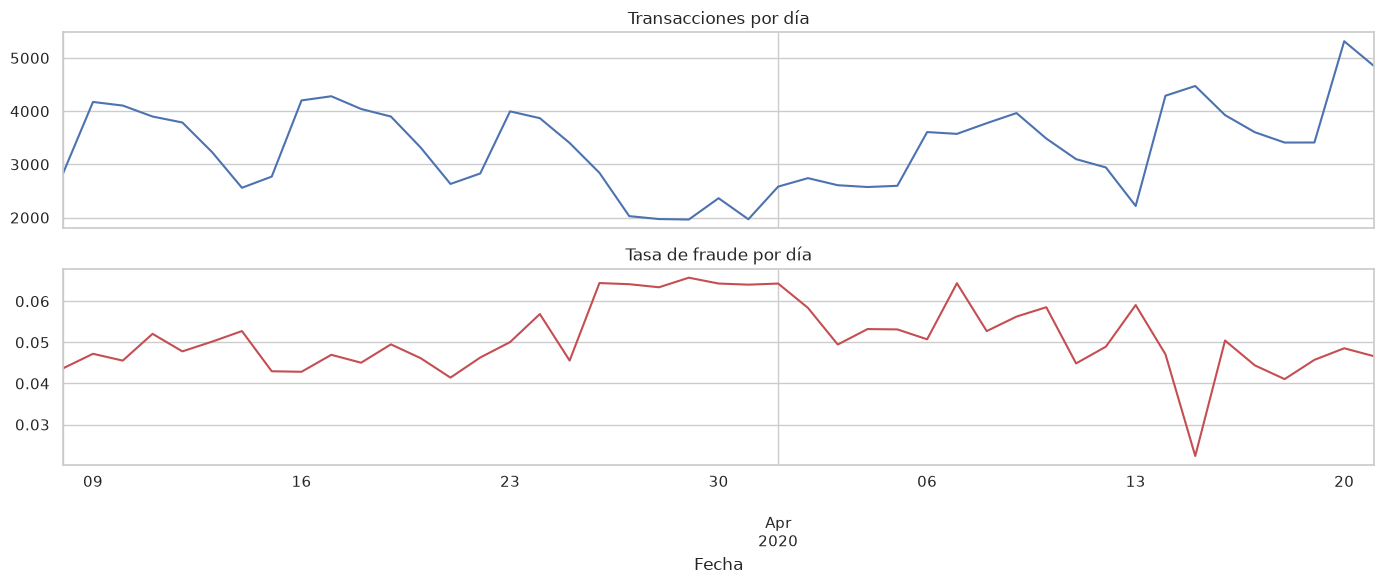

In [35]:
daily = (
    df.set_index("fecha")
    .resample("D")["fraude"]
    .agg(transacciones="size", tasa_fraude="mean")
)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
daily["transacciones"].plot(ax=axes[0], color="#4C72B0", title="Transacciones por día")
daily["tasa_fraude"].plot(ax=axes[1], color="#C44E52", title="Tasa de fraude por día")
axes[1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()


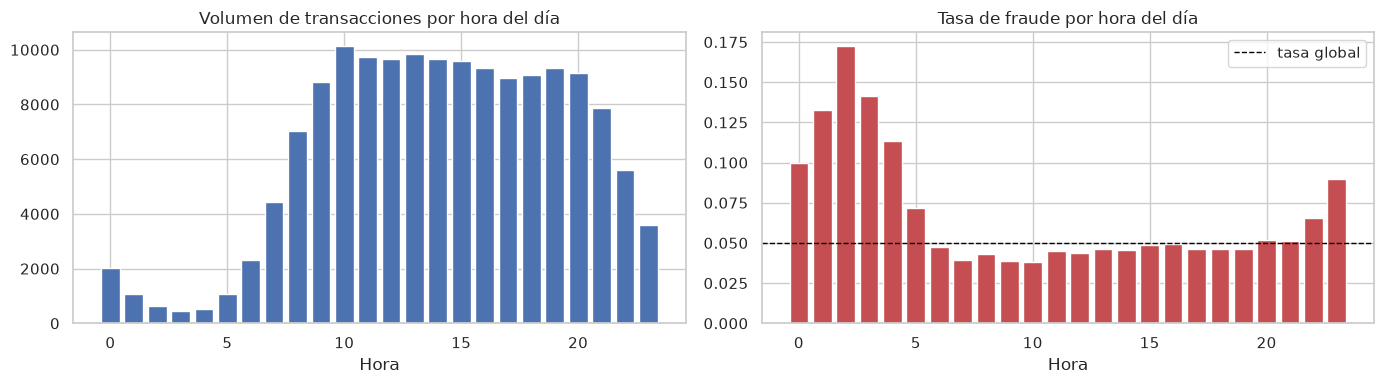

In [36]:
df["hora"] = df["fecha"].dt.hour
hourly = df.groupby("hora")["fraude"].agg(transacciones="size", tasa_fraude="mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(hourly.index, hourly["transacciones"], color="#4C72B0")
axes[0].set_title("Volumen de transacciones por hora del día")
axes[0].set_xlabel("Hora")

axes[1].bar(hourly.index, hourly["tasa_fraude"], color="#C44E52")
axes[1].axhline(df["fraude"].mean(), color="black", linestyle="--", linewidth=1, label="tasa global")
axes[1].set_title("Tasa de fraude por hora del día")
axes[1].set_xlabel("Hora")
axes[1].legend()
plt.tight_layout()
plt.show()


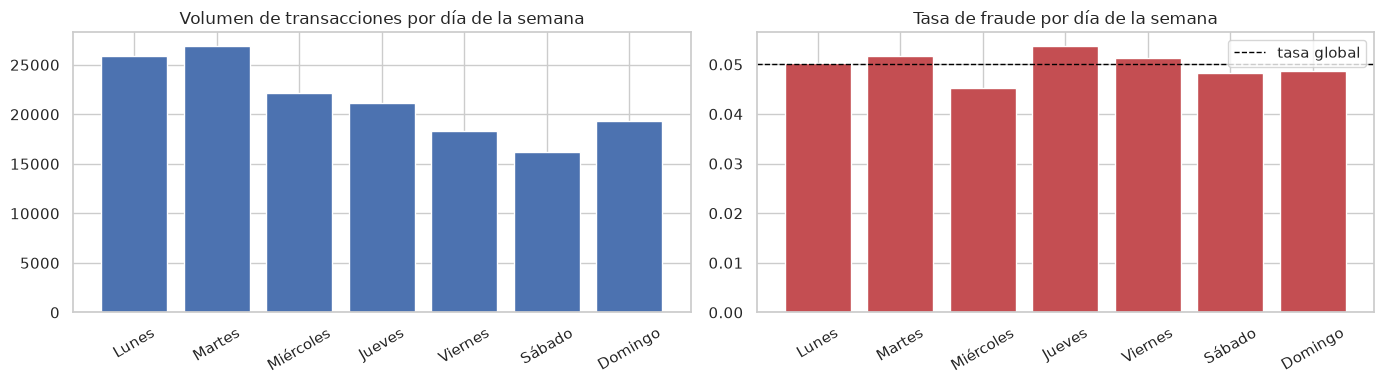

In [37]:
dias_semana = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
df["dia_semana"] = df["fecha"].dt.dayofweek
weekly = df.groupby("dia_semana")["fraude"].agg(transacciones="size", tasa_fraude="mean")
weekly.index = [dias_semana[i] for i in weekly.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(weekly.index, weekly["transacciones"], color="#4C72B0")
axes[0].set_title("Volumen de transacciones por día de la semana")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(weekly.index, weekly["tasa_fraude"], color="#C44E52")
axes[1].axhline(df["fraude"].mean(), color="black", linestyle="--", linewidth=1, label="tasa global")
axes[1].set_title("Tasa de fraude por día de la semana")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()
plt.tight_layout()
plt.show()


El dataset cubre **45 días** (2020-03-08 a 2020-04-21). No se observa una tendencia marcada
de drift en el volumen ni en la tasa de fraude día a día, pero sí aparece un **patrón
horario fuerte**: la franja de madrugada (0-5am) concentra una tasa de fraude de ~11.3%,
más del doble que el resto del día (~4.7%), aunque con mucho menor volumen de transacciones.
Este patrón horario es una señal simple y accionable (feature `hora_del_día` o `es_madrugada`)
para el modelado. En cambio, el **día de la semana no muestra un patrón relevante**: la tasa
de fraude se mantiene estable entre 4.5% y 5.4% en los siete días, por lo que no aporta
señal adicional por sí sola. De todas formas, la existencia de variación temporal — diaria u
horaria — refuerza la decisión (ya tomada en el plan de trabajo) de usar un **split temporal**
(train/val/test por fecha) en vez de un split aleatorio, para simular mejor las condiciones
de producción.

## 12. Conclusiones y próximos pasos

**Hallazgos clave:**
- Dataset de 150,000 transacciones, sin filas duplicadas, cubriendo 45 días (marzo-abril 2020).
- **Fuerte desbalance de clases**: 5% fraude (7,500 casos) vs. 95% legítimas.
- La tabla de hipótesis (Sección 2) sugiere que las columnas anonimizadas corresponden a
  señales de negocio típicas de fraude: score/flags de verificación (`n`, `o`, `p`,
  `score`), historial del comprador (`c`, `l`, `m`), país/categoría (`g`, `j`) y variables
  de conteo/recencia (`d`, `f`, `h`).
- **`monto`**: los fraudes tienden a tener montos más altos y más dispersos — crítico para la
  ecuación de beneficio del notebook `0_getting_started`, ya que no detectar un fraude de
  monto alto es mucho más costoso.
- **`score`**: señal útil pero con relación no lineal al fraude (mayor tasa en los extremos,
  especialmente en el bucket 80-100); es la variable individual más relevante según mutual
  information.
- **`g` (país)** y **`j` (categoría, alta cardinalidad ~8,300 valores)**: ambas muestran
  tasas de fraude diferenciadas; `j` requerirá frequency/target encoding.
- **`o`**: 73% de nulos, y el missingness es en sí mismo predictivo (MNAR) — tratar como
  flag/categoría, no imputar ciegamente.
- **`a`, `h`, `n`, `p`**: variables categóricas/ordinales de baja cardinalidad con señal
  aprovechable directamente.
- **`b`, `c`, `d`, `e`, `f`, `l`, `m`**: diferencias de medias entre clases moderadas;
  algunas muy sesgadas (`c`, `l`, `m`) y con nulos que deben imputarse.
- **`k` es un identificador único** (150,000 valores distintos, uno por fila) y no una
  variable de negocio — se descarta como feature para evitar que el modelo memorice en vez
  de generalizar.
- Ninguna variable numérica individual tiene correlación lineal fuerte con `fraude`, y la
  correlación de Spearman entre variables explicativas (`d`-`m`, `f`-`l`) sugiere posible
  redundancia — la señal está distribuida, lo que favorece modelos no lineales basados en
  árboles.
- Patrón horario fuerte: la madrugada (0-5am) más que duplica la tasa de fraude del resto
  del día.

**Próximo paso:** notebook `2_feature_engineering` para construir el pipeline de limpieza,
imputación (incluyendo flags de missingness donde corresponda, como `o`), encoding de
categóricas (`g`, `j`), features temporales (hora del día) y el split temporal
train/val/test, antes de pasar al modelado (Regresión Logística, Random Forest, XGBoost,
LightGBM) evaluado con la ecuación de beneficio.